   Feature_1  Feature_2
0  -7.459200   6.479711
1 -10.115891  -6.945263
2   7.267642   1.003212
3  -2.979727   7.258068
4  -5.438170  -7.369800


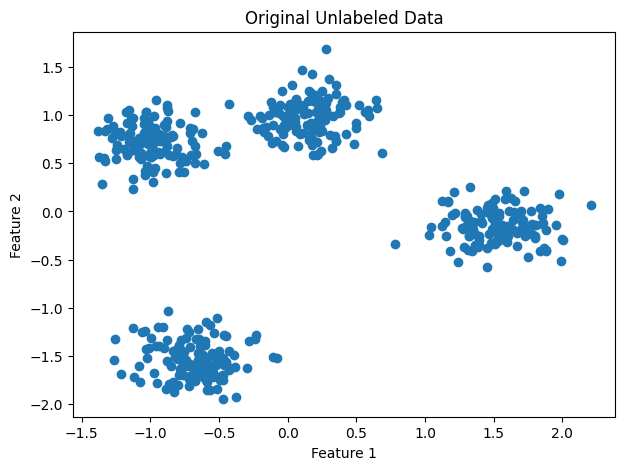

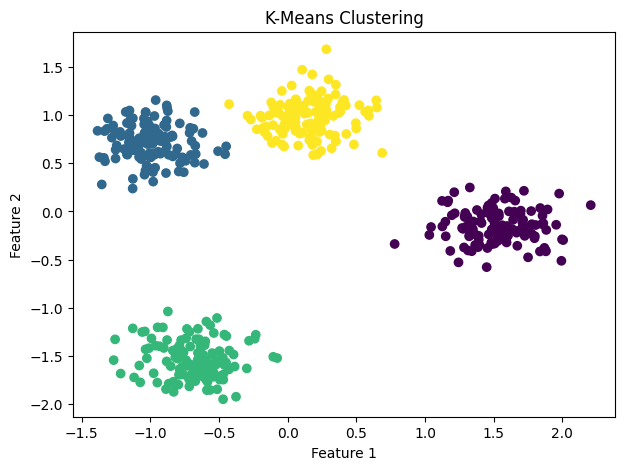

K-Means Silhouette Score: 0.755747194151021


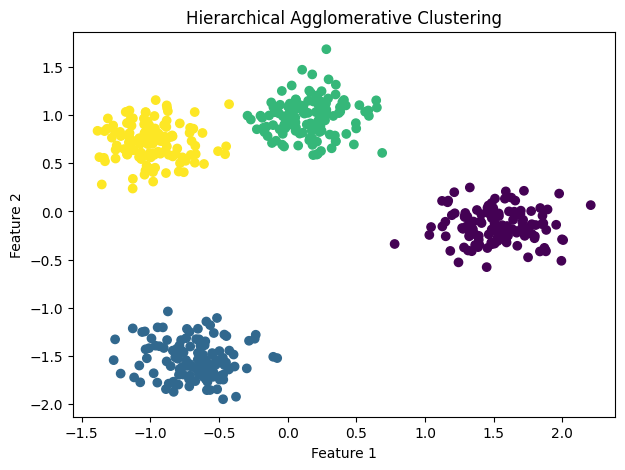

Hierarchical Silhouette Score: 0.7549335038674485


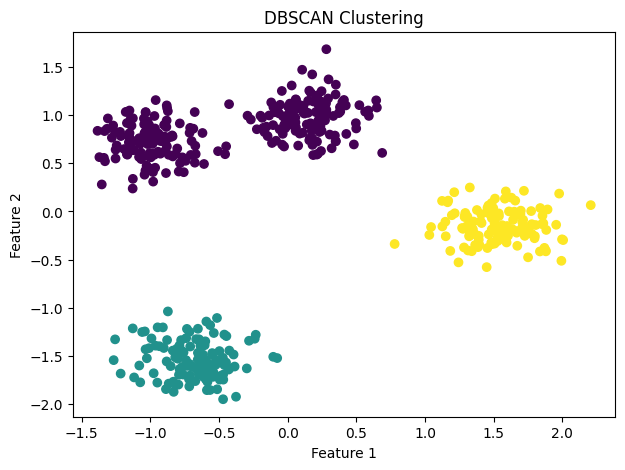

DBSCAN Cluster Labels:
DBSCAN_Cluster
0    250
1    125
2    125
Name: count, dtype: int64
DBSCAN Silhouette Score: 0.7262382921953023


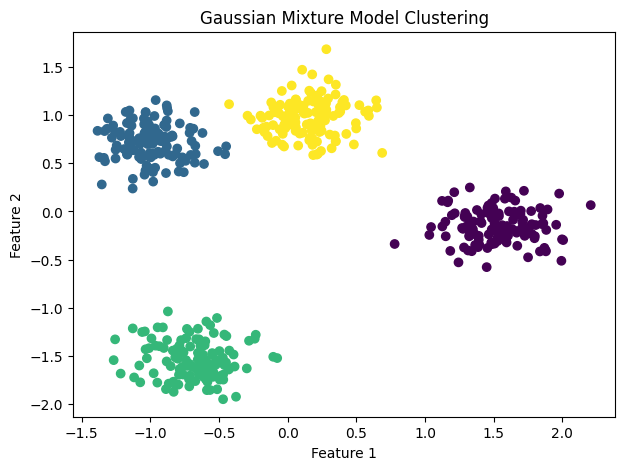

GMM Silhouette Score: 0.755747194151021
   Feature_1  Feature_2  KMeans_Cluster  Hierarchical_Cluster  DBSCAN_Cluster  \
0  -7.459200   6.479711               1                     3               0   
1 -10.115891  -6.945263               2                     1               1   
2   7.267642   1.003212               0                     0               2   
3  -2.979727   7.258068               3                     2               0   
4  -5.438170  -7.369800               2                     1               1   

   GMM_Cluster  
0            1  
1            2  
2            0  
3            3  
4            2  


In [1]:
# ==========================================
# Introduction to Clustering
# K-Means, Hierarchical, DBSCAN, and GMM
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# -------------------------------
# 1. Create sample data
# -------------------------------

X, true_labels = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])

print(df.head())

# -------------------------------
# 2. Scale the data
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# -------------------------------
# 3. Visualize original data
# -------------------------------

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.title("Original Unlabeled Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# -------------------------------
# 4. K-Means clustering
# -------------------------------

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["KMeans_Cluster"])
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("K-Means Silhouette Score:",
      silhouette_score(X_scaled, df["KMeans_Cluster"]))

# -------------------------------
# 5. Hierarchical clustering
# -------------------------------

hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

df["Hierarchical_Cluster"] = hierarchical.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["Hierarchical_Cluster"])
plt.title("Hierarchical Agglomerative Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Hierarchical Silhouette Score:",
      silhouette_score(X_scaled, df["Hierarchical_Cluster"]))

# -------------------------------
# 6. DBSCAN clustering
# -------------------------------

dbscan = DBSCAN(eps=0.35, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["DBSCAN_Cluster"])
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# DBSCAN may label some points as -1 noise.
print("DBSCAN Cluster Labels:")
print(df["DBSCAN_Cluster"].value_counts())

# Silhouette score only works properly if more than 1 cluster exists
# and not all points are noise.
dbscan_labels = df["DBSCAN_Cluster"]

if len(set(dbscan_labels)) > 1 and len(set(dbscan_labels)) < len(dbscan_labels):
    print("DBSCAN Silhouette Score:",
          silhouette_score(X_scaled, dbscan_labels))

# -------------------------------
# 7. Gaussian Mixture Model
# -------------------------------

gmm = GaussianMixture(n_components=4, random_state=42)
df["GMM_Cluster"] = gmm.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["GMM_Cluster"])
plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("GMM Silhouette Score:",
      silhouette_score(X_scaled, df["GMM_Cluster"]))

# -------------------------------
# 8. Final dataframe
# -------------------------------

print(df.head())